In [ ]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("sumedh1507/college-student-placement")

# print("Path to dataset files:", path)

100%|██████████| 108k/108k [00:00<00:00, 186kB/s]

Extracting files...
Path to dataset files: /Users/nirmal/.cache/kagglehub/datasets/sumedh1507/college-student-placement/versions/1


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [4]:
#load dataset
df=pd.read_csv('placement.csv', encoding='utf-8')

df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [5]:
df.columns

Index(['College_ID', 'IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Internship_Experience', 'Extra_Curricular_Score',
       'Communication_Skills', 'Projects_Completed', 'Placement'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


In [7]:
#encode categorical variables
from sklearn.preprocessing import LabelEncoder

college_encoder = LabelEncoder()  
df['College_ID'] = college_encoder.fit_transform(df['College_ID'])

df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,29,107,6.61,6.28,8,No,8,8,4,No
1,60,97,5.52,5.37,8,No,7,8,0,No
2,35,109,5.36,5.83,9,No,3,1,1,No
3,54,122,5.47,5.75,6,Yes,1,6,1,No
4,3,96,7.91,7.69,7,No,8,10,2,No


In [9]:
#convert No and Yes to 0 and 1
df['Internship_Experience'] = df['Internship_Experience'].map({'No': 0, 'Yes': 1})
df['Placement'] = df['Placement'].map({'No': 0, 'Yes': 1})

In [10]:
df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,29,107,6.61,6.28,8,0,8,8,4,0
1,60,97,5.52,5.37,8,0,7,8,0,0
2,35,109,5.36,5.83,9,0,3,1,1,0
3,54,122,5.47,5.75,6,1,1,6,1,0
4,3,96,7.91,7.69,7,0,8,10,2,0


In [11]:
df2=df.copy()

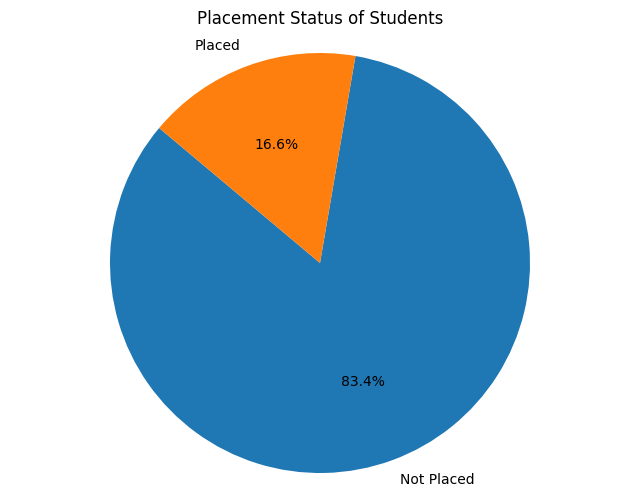

In [12]:
#visualise percentage of students placed
#pie chart
plt.figure(figsize=(8, 6))
plt.pie(df2['Placement'].value_counts(), labels=['Not Placed', 'Placed'], autopct='%1.1f%%', startangle=140)
plt.title('Placement Status of Students')  
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is circular.
plt.show()

In [ ]:
y= df2['Placement']
X= df2.drop(['Placement'], axis=1)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#classfication algorithms
# Logistic Regression
# Naive Bayes
# Decision Tree
# Random Forest


In [24]:
#randomlt get one record
record=df.sample(n=1, random_state=42)
record=tuple(record.values.tolist()[0])
record

(28.0, 139.0, 7.29, 7.24, 8.0, 0.0, 8.0, 4.0, 4.0, 0.0)

In [15]:
#logoistic regression
from sklearn.linear_model import LogisticRegression

log_model= LogisticRegression()
log_model.fit(X_train, y_train)

#evaluate the model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
y_pred_log = log_model.predict(X_test)
accuracy_log = accuracy_score(y_test, y_pred_log)
confusion_log = confusion_matrix(y_test, y_pred_log)
report_log = classification_report(y_test, y_pred_log)
print("Logistic Regression Accuracy:", accuracy_log)
print("Confusion Matrix:\n", confusion_log)
print("Classification Report:\n", report_log)


Logistic Regression Accuracy: 0.888
Confusion Matrix:
 [[1592   82]
 [ 142  184]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.93      1674
           1       0.69      0.56      0.62       326

    accuracy                           0.89      2000
   macro avg       0.80      0.76      0.78      2000
weighted avg       0.88      0.89      0.88      2000



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linea

In [16]:
#naive bayes
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
#evaluate the model
y_pred_nb = nb_model.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
confusion_nb = confusion_matrix(y_test, y_pred_nb)
report_nb = classification_report(y_test, y_pred_nb)
print("Naive Bayes Accuracy:", accuracy_nb)
print("Confusion Matrix:\n", confusion_nb)
print("Classification Report:\n", report_nb)


Naive Bayes Accuracy: 0.9095
Confusion Matrix:
 [[1609   65]
 [ 116  210]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.95      1674
           1       0.76      0.64      0.70       326

    accuracy                           0.91      2000
   macro avg       0.85      0.80      0.82      2000
weighted avg       0.91      0.91      0.91      2000



In [17]:
#decision tree
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
#evaluate the model
y_pred_dt = dt_model.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
confusion_dt = confusion_matrix(y_test, y_pred_dt)
report_dt = classification_report(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)
print("Confusion Matrix:\n", confusion_dt)
print("Classification Report:\n", report_dt)


Decision Tree Accuracy: 1.0
Confusion Matrix:
 [[1674    0]
 [   0  326]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1674
           1       1.00      1.00      1.00       326

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [18]:
# random forest
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
#evaluate the model
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
confusion_rf = confusion_matrix(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)
print("Confusion Matrix:\n", confusion_rf)
print("Classification Report:\n", report_rf)


Random Forest Accuracy: 1.0
Confusion Matrix:
 [[1674    0]
 [   0  326]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1674
           1       1.00      1.00      1.00       326

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



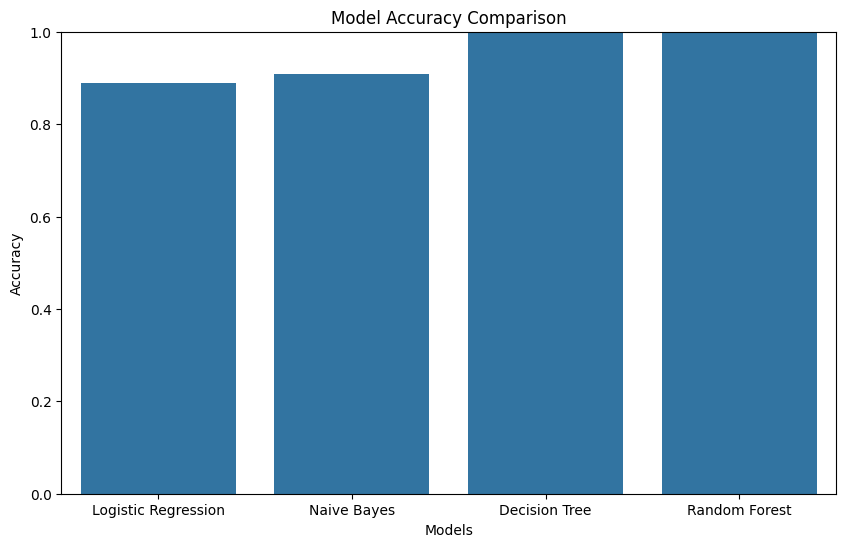

In [19]:
#visualise the results
plt.figure(figsize=(10, 6))
sns.barplot(x=['Logistic Regression', 'Naive Bayes', 'Decision Tree', 'Random Forest'], 
            y=[accuracy_log, accuracy_nb, accuracy_dt, accuracy_rf])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Models')
plt.ylim(0, 1)  # Set y-axis limit to 0-
plt.show()

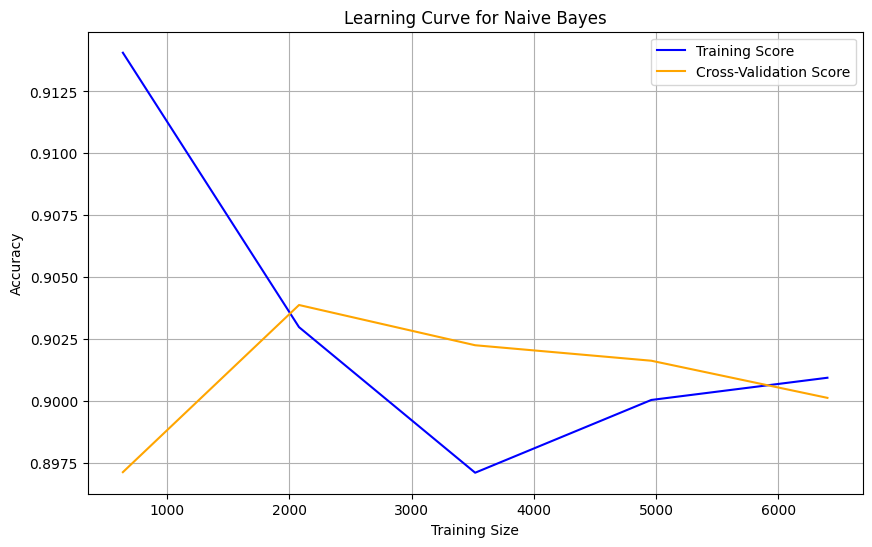

In [20]:
#learning curve for naives bayes
from sklearn.model_selection import learning_curve
train_sizes, train_scores, test_scores = learning_curve(nb_model, X_train, y_train
, cv=5, scoring='accuracy', n_jobs=-1)
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training Score', color='blue')
plt.plot(train_sizes, test_scores_mean, label='Cross-Validation Score', color='orange')

plt.title('Learning Curve for Naive Bayes')
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()


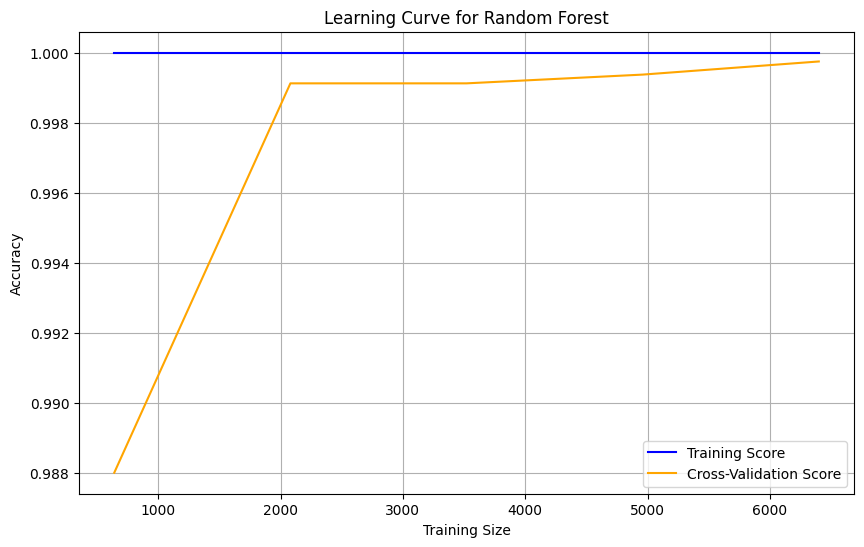

In [22]:
#training curve for random forest
train_sizes, train_scores, test_scores = learning_curve(rf_model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training Score', color='blue')
plt.plot(train_sizes, test_scores_mean, label='Cross-Validation Score', color='orange')
plt.title('Learning Curve for Random Forest')
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

In [35]:
#choosing naives bayes as the best model
#make predictions on new data

prediction = nb_model.predict([[28.0, 139.0, 7.29, 7.24, 8.0, 0.0, 8.0, 4.0, 4.0]])
prediction

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


array([0])

In [34]:
prediction = nb_model.predict([[28.0, 139.0, 8, 8, 8.0, 1, 8.0, 4.0, 4.0]])
prediction

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


array([1])

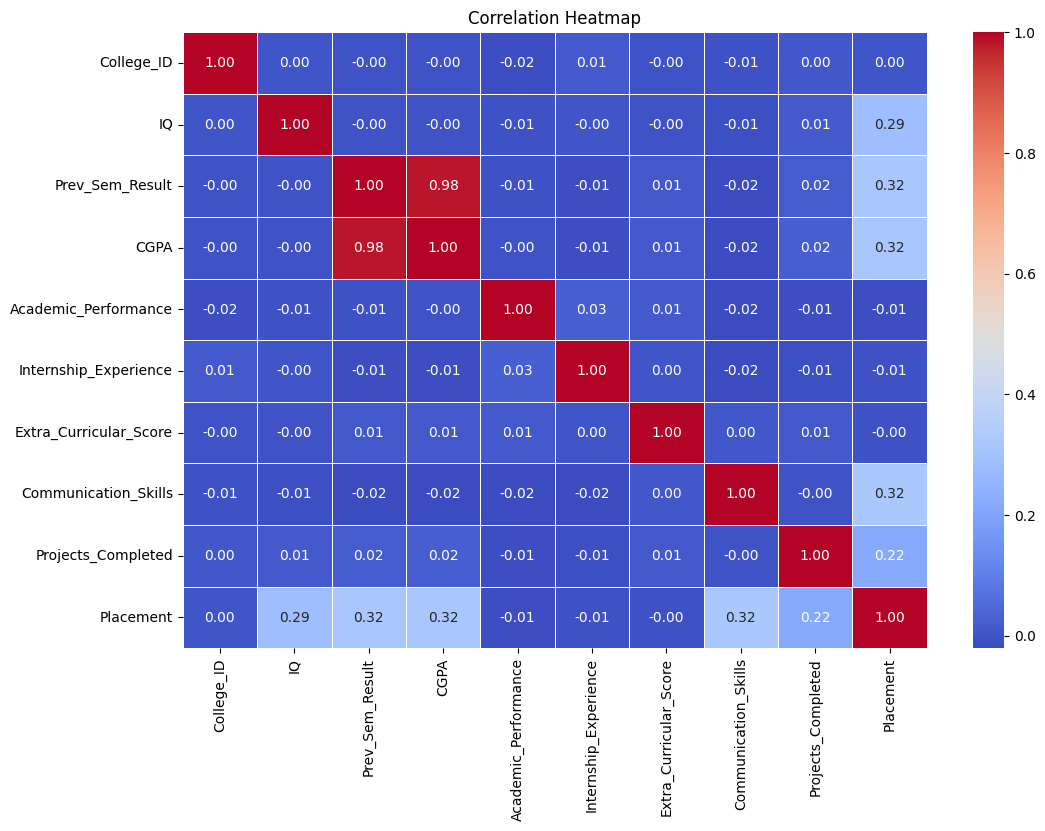

In [36]:
#correlation visualisayion between features
plt.figure(figsize=(12, 8))
sns.heatmap(df2.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()